# Portfolio Optimization: Minimum Variance and Maximum Sharpe

This notebook constructs and evaluates optimized portfolios across four ETFs:

- **ACWI** — Global equities (MSCI ACWI)
- **AGG** — US aggregate bonds
- **GLD** — Gold
- **BSV** — Short-term bonds

**Methodology:**
- Training period: 2019-01-01 to 2022-12-28
- Test period: full year 2023 (out-of-sample)
- Covariance estimation: Ledoit-Wolf shrinkage (applied once, held constant across all approaches)
- Rebalancing: none — weights are fixed at the start of 2023
- Risk-free rate: 0% (simplifying assumption)
- Benchmark: Permanent Portfolio (25% each asset)

**Key question:** Can a constrained minimum variance portfolio, estimated using only pre-2023 information, provide a more defensible allocation than maximum Sharpe alternatives that rely on noisy expected return estimates?

### Final methodology selected

The final submitted strategy is the constrained Minimum Variance portfolio using Ledoit-Wolf covariance shrinkage and a 40% maximum allocation per ETF.

Maximum Sharpe portfolios are included only as comparison cases to illustrate the sensitivity of optimized portfolios to expected return assumptions.

## 1. Imports

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## 2. Data download and preparation

In [44]:
tickers = ["ACWI", "AGG", "GLD", "BSV"]

prices = yf.download(
    tickers,
    start="2019-01-01",
    end="2024-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.reindex(columns=tickers)
prices = prices.dropna()

assert list(prices.columns) == tickers

In [45]:
returns = prices.pct_change().dropna()

# Training ends before the 2022-12-29 effective date to avoid look-ahead bias.
returns_2019_2022 = returns.loc["2019-01-01":"2022-12-28"]
returns_2020_2022 = returns.loc["2020-01-01":"2022-12-28"]

# Full 2023 out-of-sample test period.
returns_2023 = returns.loc["2023-01-01":"2023-12-31"]

trading_days   = 252
risk_free_rate = 0.00

print(f"2019-2022 observations: {len(returns_2019_2022)}")
print(f"2020-2022 observations: {len(returns_2020_2022)}")
print(f"2023 test observations: {len(returns_2023)}")

2019-2022 observations: 1005
2020-2022 observations: 754
2023 test observations: 250


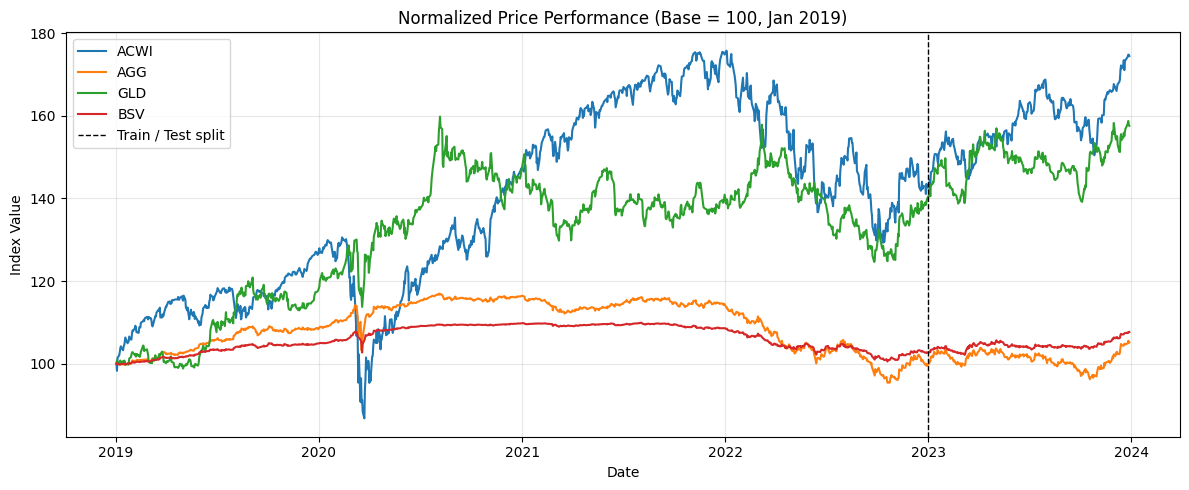

In [46]:
normalized_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(12, 5))
for ticker in tickers:
    plt.plot(normalized_prices.index, normalized_prices[ticker], label=ticker)

plt.axvline(pd.Timestamp("2023-01-01"), color="black", linestyle="--", linewidth=1, label="Train / Test split")
plt.title("Normalized Price Performance (Base = 100, Jan 2019)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Helper functions

In [47]:
def annualized_return(daily_returns):

    return daily_returns.mean() * trading_days


def portfolio_return(weights, expected_returns):
    return np.dot(weights, expected_returns)


def portfolio_volatility(weights, cov_matrix):
    return np.sqrt(weights.T @ cov_matrix @ weights)


def portfolio_sharpe(weights, expected_returns, cov_matrix, rf=0.00):
    return (portfolio_return(weights, expected_returns) - rf) / portfolio_volatility(weights, cov_matrix)

def evaluate_2023(weights):
    weights = pd.Series(weights, index=tickers)
    pr = returns_2023[tickers].dot(weights)

    ann_ret = pr.mean() * trading_days
    ann_vol = pr.std() * np.sqrt(trading_days)
    sharpe = ann_ret / ann_vol
    cum_ret = (1 + pr).prod() - 1

    cumulative = (1 + pr).cumprod()
    max_dd = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min()

    return ann_ret, ann_vol, sharpe, cum_ret, max_dd

## 4. Covariance matrix — Ledoit-Wolf shrinkage

We estimate a **single** covariance matrix using the full 2019-2022 training period and Ledoit-Wolf shrinkage.
This matrix is held **constant across all optimization approaches** below.

Why Ledoit-Wolf? The sample covariance matrix with ~1000 observations and 4 assets is noisy — small-sample estimation error is amplified by the optimizer into extreme weights. Ledoit-Wolf applies an analytic shrinkage correction that reduces this error without introducing arbitrary regularization parameters. It is the standard approach in empirical asset management research (Ledoit & Wolf, 2004).

In [48]:
lw = LedoitWolf().fit(returns_2019_2022[tickers].values)

cov_annual = lw.covariance_ * trading_days
cov_df = pd.DataFrame(cov_annual, index=tickers, columns=tickers)

cov_df = pd.DataFrame(cov_annual, index=tickers, columns=tickers)
print("Annualised covariance matrix (Ledoit-Wolf, 2019-2022):")
print(cov_df.round(6))

# Shrinkage coefficient — how much LW pulled toward the identity
print(f"\nLedoit-Wolf shrinkage coefficient: {lw.shrinkage_:.4f}")

Annualised covariance matrix (Ledoit-Wolf, 2019-2022):
       ACWI    AGG    GLD    BSV
ACWI 0.0452 0.0023 0.0051 0.0007
AGG  0.0023 0.0044 0.0034 0.0011
GLD  0.0051 0.0034 0.0233 0.0016
BSV  0.0007 0.0011 0.0016 0.0013

Ledoit-Wolf shrinkage coefficient: 0.0325


The diagonal entries confirm that ACWI and GLD are the highest-volatility assets, while BSV has the lowest variance. This explains why the minimum variance optimizer allocates heavily to BSV and AGG (subject to the 40% cap): these are the lowest-variance assets in the universe. GLD receives a moderate allocation due to its low correlation with equities despite its higher absolute volatility.

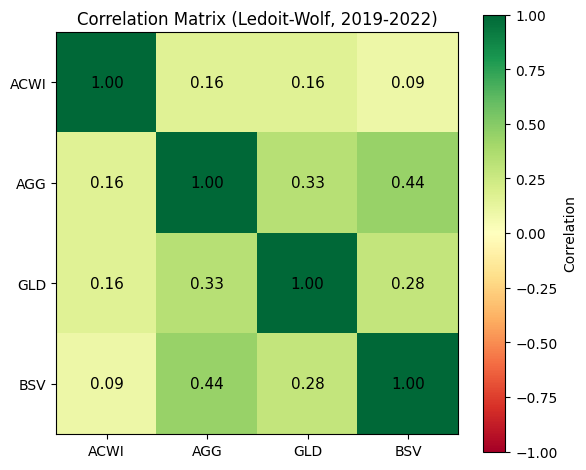

In [49]:
# Correlation matrix for interpretability
vols  = np.sqrt(np.diag(cov_annual))
corr  = cov_annual / np.outer(vols, vols)
corr_df = pd.DataFrame(corr, index=tickers, columns=tickers)

plt.figure(figsize=(6, 5))
im = plt.imshow(corr_df.values, vmin=-1, vmax=1, cmap="RdYlGn")
plt.xticks(range(len(tickers)), tickers)
plt.yticks(range(len(tickers)), tickers)
plt.colorbar(im, label="Correlation")
plt.title("Correlation Matrix (Ledoit-Wolf, 2019-2022)")
for i in range(len(tickers)):
    for j in range(len(tickers)):
        plt.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Asset-level summary (training period)

In [50]:
summary = pd.DataFrame(index=tickers)
summary["Ann. Return"]     = returns_2019_2022.mean() * trading_days
summary["Ann. Volatility"] = returns_2019_2022.std()  * np.sqrt(trading_days)
summary["Sharpe Ratio"]    = summary["Ann. Return"] / summary["Ann. Volatility"]

display_summary = summary.copy()
display_summary["Ann. Return"]     = display_summary["Ann. Return"].map("{:.2%}".format)
display_summary["Ann. Volatility"] = display_summary["Ann. Volatility"].map("{:.2%}".format)
display_summary["Sharpe Ratio"]    = display_summary["Sharpe Ratio"].map("{:.4f}".format)

print("Asset-level statistics, 2019-2022 training period:")
display(display_summary)

Asset-level statistics, 2019-2022 training period:


,Ann. Return,Ann. Volatility,Sharpe Ratio
ACWI,10.95%,21.48%,0.5100
AGG,0.10%,6.29%,0.0165
GLD,9.32%,15.31%,0.6087
BSV,0.70%,2.68%,0.2610


## 6. Optimizer functions

In [51]:
def minimize_variance(cov_matrix, max_weight=1.0):
    """
    Long-only minimum variance portfolio.
    max_weight caps concentration (e.g. 0.40 = 40% per asset).
    """
    n = cov_matrix.shape[0]
    result = minimize(
        lambda w: portfolio_volatility(w, cov_matrix),
        x0=np.repeat(1 / n, n),
        method="SLSQP",
        bounds=[(0, max_weight)] * n,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1}
    )
    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")
    return result.x


def maximize_sharpe(expected_returns, cov_matrix, rf=0.00):

    n = len(expected_returns)
    result = minimize(
        lambda w: -portfolio_sharpe(w, expected_returns, cov_matrix, rf),
        x0=np.repeat(1 / n, n),
        method="SLSQP",
        bounds=[(0, 1)] * n,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1}
    )
    if not result.success:
        raise ValueError(f"Optimization failed: {result.message}")
    return result.x

## 7. Minimum variance portfolio (2019-2022, 40% cap)

Unconstrained minimum variance tends to concentrate in the lowest-volatility defensive asset, BSV. This creates an excessively concentrated allocation rather than a diversified portfolio. A 40% cap is therefore used as a practical concentration-control constraint. It prevents the optimizer from collapsing into a single asset while still allowing meaningful tilts away from the equal-weight benchmark.

In [52]:
weights_minvar = minimize_variance(cov_annual, max_weight=0.40)

ret_mv, vol_mv, sr_mv, cum_mv, mdd_mv = evaluate_2023(weights_minvar)

w_minvar_df = pd.DataFrame({"Weight": weights_minvar}, index=tickers)
w_minvar_df["Weight"] = w_minvar_df["Weight"].map("{:.2%}".format)

print("Minimum Variance Portfolio Weights (40% cap):")
display(w_minvar_df)

print(f"\n2023 Realized Annual Return:     {ret_mv:.2%}")
print(f"2023 Realized Annual Volatility: {vol_mv:.2%}")
print(f"2023 Realized Sharpe Ratio:      {sr_mv:.4f}")
print(f"2023 Cumulative Return:          {cum_mv:.2%}")
print(f"2023 Max Drawdown:               {mdd_mv:.2%}")

Minimum Variance Portfolio Weights (40% cap):


,Weight
ACWI,7.70%
AGG,40.00%
GLD,12.30%
BSV,40.00%



2023 Realized Annual Return:     7.49%
2023 Realized Annual Volatility: 5.62%
2023 Realized Sharpe Ratio:      1.3324
2023 Cumulative Return:          7.55%
2023 Max Drawdown:               -4.63%


The optimized portfolio binds at the 40% cap for AGG and BSV. This is economically intuitive: both assets have relatively low volatility compared with ACWI, while BSV provides the strongest short-duration defensive exposure. GLD receives a moderate allocation as a diversifier, and ACWI receives a small allocation due to its higher volatility.

## 8. Maximum Sharpe: Three return estimation approaches

Maximum Sharpe optimization requires expected return inputs in addition to the covariance matrix. Unlike minimum variance, it is highly sensitive to these inputs — estimation error in means gets amplified by the optimizer into extreme weight tilts. This section tests three return estimation methods to quantify that sensitivity.

**Important design decision:** The covariance matrix is held fixed (Ledoit-Wolf, 2019-2022) across all three approaches. This isolates the effect of return estimation on out-of-sample performance. Changing both returns and covariances simultaneously would confound the comparison.

- **Approach A**: Expected returns from 2020-2022 only. Rationale: excludes the 2019 bull run, focusing on the post-COVID macro regime.
- **Approach B**: Expected returns from the full 2019-2022 training window. Rationale: more data reduces sampling variance on means — in theory.
- **Approach C**: Forward-looking assumptions (analyst consensus priors). Rationale: historical means are dominated by 2022 drawdowns, which may not reflect structural returns.

### Approach A — Expected returns from 2020-2022

In [53]:
exp_returns_A = annualized_return(returns_2020_2022)

print("Expected returns used (Approach A, 2020-2022):")
print(exp_returns_A.map("{:.2%}".format))

weights_A = maximize_sharpe(exp_returns_A.values, cov_annual)

ret_A, vol_A, sr_A, cum_A, mdd_A = evaluate_2023(weights_A)

w_A_df = pd.DataFrame({"Weight": weights_A}, index=tickers)
w_A_df["Weight"] = w_A_df["Weight"].map("{:.2%}".format)

print("\nApproach A Weights:")
display(w_A_df)

print(f"\n2023 Realized Annual Return:     {ret_A:.2%}")
print(f"2023 Realized Annual Volatility: {vol_A:.2%}")
print(f"2023 Realized Sharpe Ratio:      {sr_A:.4f}")
print(f"2023 Cumulative Return:          {cum_A:.2%}")
print(f"2023 Max Drawdown:               {mdd_A:.2%}")

Expected returns used (Approach A, 2020-2022):
Ticker
ACWI     6.47%
AGG     -2.57%
GLD      6.73%
BSV     -0.67%
dtype: object

Approach A Weights:


,Weight
ACWI,30.03%
AGG,0.00%
GLD,69.97%
BSV,0.00%



2023 Realized Annual Return:     15.38%
2023 Realized Annual Volatility: 10.43%
2023 Realized Sharpe Ratio:      1.4739
2023 Cumulative Return:          15.85%
2023 Max Drawdown:               -7.90%


### Approach B — Expected returns from 2019-2022

In [54]:
exp_returns_B = annualized_return(returns_2019_2022)

print("Expected returns used (Approach B, 2019-2022):")
print(exp_returns_B.map("{:.2%}".format))

weights_B = maximize_sharpe(exp_returns_B.values, cov_annual)

ret_B, vol_B, sr_B, cum_B, mdd_B = evaluate_2023(weights_B)

w_B_df = pd.DataFrame({"Weight": weights_B}, index=tickers)
w_B_df["Weight"] = w_B_df["Weight"].map("{:.2%}".format)

print("\nApproach B Weights:")
display(w_B_df)

print(f"\n2023 Realized Annual Return:     {ret_B:.2%}")
print(f"2023 Realized Annual Volatility: {vol_B:.2%}")
print(f"2023 Realized Sharpe Ratio:      {sr_B:.4f}")
print(f"2023 Cumulative Return:          {cum_B:.2%}")
print(f"2023 Max Drawdown:               {mdd_B:.2%}")

Expected returns used (Approach B, 2019-2022):
Ticker
ACWI    10.95%
AGG      0.10%
GLD      9.32%
BSV      0.70%
dtype: object

Approach B Weights:


,Weight
ACWI,35.98%
AGG,0.00%
GLD,63.46%
BSV,0.55%



2023 Realized Annual Return:     15.82%
2023 Realized Annual Volatility: 10.01%
2023 Realized Sharpe Ratio:      1.5795
2023 Cumulative Return:          16.41%
2023 Max Drawdown:               -7.87%


### Approach C — Forward-looking return assumptions

Historical sample means for this dataset are heavily distorted by 2022 (ACWI: -18%, AGG: -13%), which pushes expected returns for equities and bonds close to zero or negative. Rather than let a single outlier year dominate the return input, Approach C uses simple illustrative forward-looking return assumptions:

| Asset | Assumption | Rationale |
|-------|-----------|----------|
| ACWI  | 7%        | Long-run global equity return assumption |
| AGG   | 4%        | Approximate intermediate bond return assumption |
| GLD   | 2%        | Conservative assumption for a non-yielding real asset |
| BSV   | 5%        | Short-duration yield environment assumption |

These assumptions are not used for the final submitted portfolio. They are included only to show how sensitive Maximum Sharpe optimization is to expected return inputs.

In [55]:
exp_returns_C = pd.Series({"ACWI": 0.07, "AGG": 0.04, "GLD": 0.02, "BSV": 0.05})

print("Expected returns used (Approach C, forward-looking):")
print(exp_returns_C.map("{:.2%}".format))

weights_C = maximize_sharpe(exp_returns_C.values, cov_annual)

ret_C, vol_C, sr_C, cum_C, mdd_C = evaluate_2023(weights_C)

w_C_df = pd.DataFrame({"Weight": weights_C}, index=tickers)
w_C_df["Weight"] = w_C_df["Weight"].map("{:.2%}".format)

print("\nApproach C Weights:")
display(w_C_df)

print(f"\n2023 Realized Annual Return:     {ret_C:.2%}")
print(f"2023 Realized Annual Volatility: {vol_C:.2%}")
print(f"2023 Realized Sharpe Ratio:      {sr_C:.4f}")
print(f"2023 Cumulative Return:          {cum_C:.2%}")
print(f"2023 Max Drawdown:               {mdd_C:.2%}")

Expected returns used (Approach C, forward-looking):
ACWI    7.00%
AGG     4.00%
GLD     2.00%
BSV     5.00%
dtype: object

Approach C Weights:


,Weight
ACWI,2.50%
AGG,0.00%
GLD,0.00%
BSV,97.50%



2023 Realized Annual Return:     5.28%
2023 Realized Annual Volatility: 3.44%
2023 Realized Sharpe Ratio:      1.5346
2023 Cumulative Return:          5.32%
2023 Max Drawdown:               -2.06%


## 9. Benchmark — Permanent Portfolio (25/25/25/25)

The Permanent Portfolio allocates equally across all four assets regardless of return or risk estimates. It is naive by construction and requires no optimization. It serves as the benchmark: any optimized portfolio that cannot beat it raises serious questions about whether the optimization added value.

In [56]:
weights_bench = np.array([0.25, 0.25, 0.25, 0.25])

ret_bench, vol_bench, sr_bench, cum_bench, mdd_bench = evaluate_2023(weights_bench)

## 10. Summary: 2023 out-of-sample performance

In [57]:
results = pd.DataFrame(
    {
        "Min Variance (40% cap)":        [ret_mv,    vol_mv,    sr_mv,    cum_mv,    mdd_mv],
        "A: MaxSharpe 2020-2022":         [ret_A,     vol_A,     sr_A,     cum_A,     mdd_A],
        "B: MaxSharpe 2019-2022":         [ret_B,     vol_B,     sr_B,     cum_B,     mdd_B],
        "C: MaxSharpe Fwd-Looking":       [ret_C,     vol_C,     sr_C,     cum_C,     mdd_C],
        "Benchmark: Perm Portfolio":      [ret_bench, vol_bench, sr_bench, cum_bench, mdd_bench],
    },
    index=["Ann. Return", "Ann. Volatility", "Sharpe Ratio", "Cum. Return", "Max Drawdown"]
).T

results_display = results.copy()
for col in ["Ann. Return", "Ann. Volatility", "Cum. Return", "Max Drawdown"]:
    results_display[col] = results_display[col].map("{:.2%}".format)
results_display["Sharpe Ratio"] = results_display["Sharpe Ratio"].map("{:.4f}".format)

print("2023 Out-of-Sample Performance Summary:")
display(results_display)

best = results["Sharpe Ratio"].idxmax()
print(f"\nBest realized Sharpe in 2023: {best} ({results.loc[best, 'Sharpe Ratio']:.4f})")

2023 Out-of-Sample Performance Summary:


,Ann. Return,Ann. Volatility,Sharpe Ratio,Cum. Return,Max Drawdown
Min Variance (40% cap),7.49%,5.62%,1.3324,7.55%,-4.63%
A: MaxSharpe 2020-2022,15.38%,10.43%,1.4739,15.85%,-7.90%
B: MaxSharpe 2019-2022,15.82%,10.01%,1.5795,16.41%,-7.87%
C: MaxSharpe Fwd-Looking,5.28%,3.44%,1.5346,5.32%,-2.06%
Benchmark: Perm Portfolio,11.18%,6.56%,1.7025,11.49%,-5.54%



Best realized Sharpe in 2023: Benchmark: Perm Portfolio (1.7025)


In [58]:
# Weights comparison table
weights_comparison = pd.DataFrame(
    {
        "Min Variance (40% cap)":  weights_minvar,
        "A: MaxSharpe 2020-2022":  weights_A,
        "B: MaxSharpe 2019-2022":  weights_B,
        "C: MaxSharpe Fwd-Looking": weights_C,
        "Benchmark: Perm Portfolio": weights_bench,
    },
    index=tickers
).T

w_display = weights_comparison.copy()
for col in tickers:
    w_display[col] = w_display[col].map("{:.2%}".format)

print("Portfolio Weights Comparison:")
display(w_display)

Portfolio Weights Comparison:


,ACWI,AGG,GLD,BSV
Min Variance (40% cap),7.70%,40.00%,12.30%,40.00%
A: MaxSharpe 2020-2022,30.03%,0.00%,69.97%,0.00%
B: MaxSharpe 2019-2022,35.98%,0.00%,63.46%,0.55%
C: MaxSharpe Fwd-Looking,2.50%,0.00%,0.00%,97.50%
Benchmark: Perm Portfolio,25.00%,25.00%,25.00%,25.00%


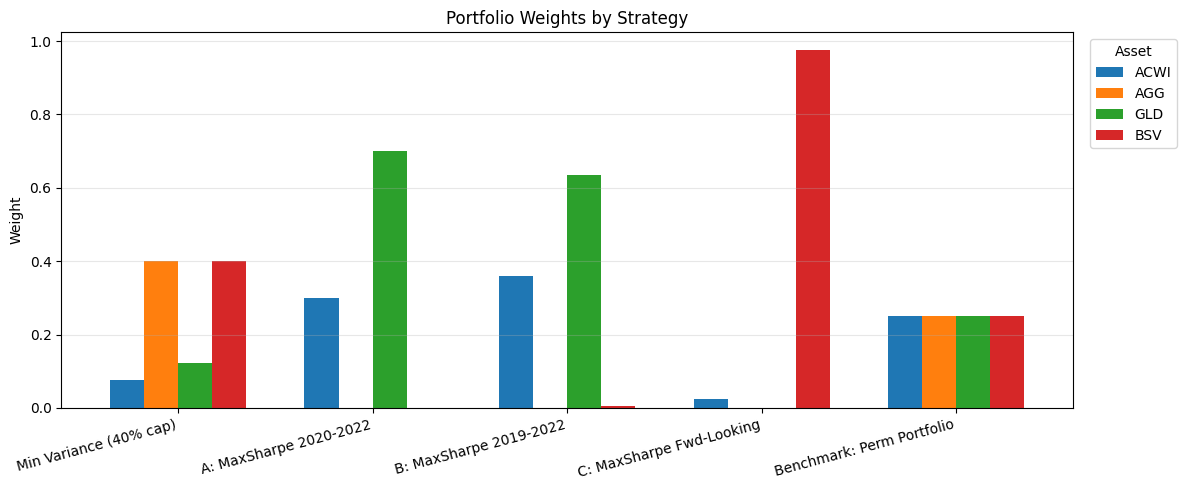

In [59]:
# Weights bar chart
weights_comparison.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.7
)
plt.title("Portfolio Weights by Strategy")
plt.ylabel("Weight")
plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Asset", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

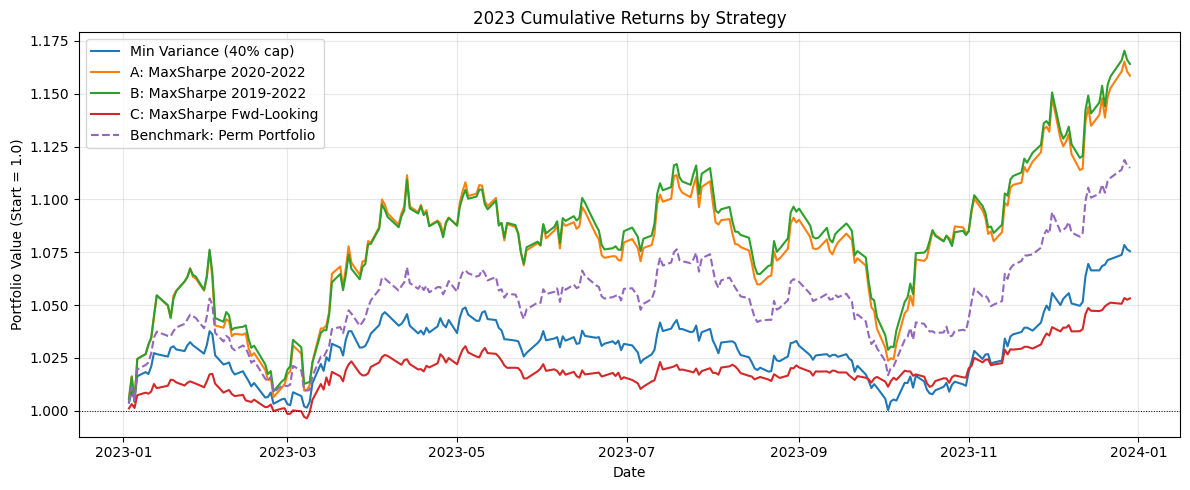

In [60]:
# Cumulative return chart (2023)
all_weights = {
    "Min Variance (40% cap)":   weights_minvar,
    "A: MaxSharpe 2020-2022":   weights_A,
    "B: MaxSharpe 2019-2022":   weights_B,
    "C: MaxSharpe Fwd-Looking": weights_C,
    "Benchmark: Perm Portfolio": weights_bench,
}

plt.figure(figsize=(12, 5))
for label, w in all_weights.items():
    pr  = returns_2023 @ w
    cum = (1 + pr).cumprod()
    ls  = "--" if "Benchmark" in label else "-"
    plt.plot(cum.index, cum, label=label, linestyle=ls)

plt.axhline(1.0, color="black", linewidth=0.7, linestyle=":")
plt.title("2023 Cumulative Returns by Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Start = 1.0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Interpretation

### What the results show

The constrained Minimum Variance portfolio produces a conservative allocation dominated by fixed income: AGG and BSV each receive the maximum 40% allocation, GLD receives a moderate share as a diversifier, and ACWI receives a small allocation due to its higher volatility. The optimizer minimizes variance and therefore favors assets with lower historical volatility.

The Maximum Sharpe portfolios are more sensitive to expected return inputs. Approaches A and B use historical average returns from different training windows. Approach C uses illustrative forward-looking assumptions. The resulting weights differ substantially across approaches because Maximum Sharpe optimization depends directly on expected returns, which are difficult to estimate reliably from short samples.

In 2023, the equal-weight benchmark achieved a higher Sharpe ratio than the constrained Minimum Variance portfolio. This was primarily because the benchmark held 25% in ACWI, while the Minimum Variance portfolio held only 7.70%. Since 2023 was a strong year for global equities, the benchmark captured more upside.

The Minimum Variance portfolio achieved lower volatility and a smaller maximum drawdown than the benchmark. This is consistent with its objective: it is designed to reduce risk, not to maximize returns in equity bull markets.

### Core methodological takeaway

Maximum Sharpe optimization is highly sensitive to expected return estimates. Small changes in expected returns can lead to large changes in portfolio weights. This is a known issue in mean-variance optimization because expected returns are much harder to estimate reliably than covariances (Michaud, 1989; Black & Litterman, 1992).

Minimum Variance optimization solves a simpler problem. It does not require expected return forecasts and relies only on the covariance matrix. Using Ledoit-Wolf shrinkage further improves the stability of the covariance estimate.

The 40% cap is necessary because unconstrained minimum variance can produce excessive concentration in the lowest-volatility asset. The constraint makes the allocation more diversified and practically usable.

### Limitations

- Single out-of-sample year (2023) is insufficient to draw statistically significant conclusions. A proper evaluation would require rolling-window backtests across multiple years.
- Risk-free rate is set to 0%, which understates the opportunity cost of capital in a 5%+ short-rate environment (2023).
- No transaction costs or rebalancing friction are modelled.
- The covariance matrix is estimated once and held fixed. In practice, covariances shift across regimes.

## Selected portfolio for submission

The final selected portfolio is the constrained Minimum Variance portfolio with Ledoit-Wolf covariance shrinkage and a 40% maximum allocation per ETF.

| Asset | Weight |
|---|---:|
| ACWI | 7.70% |
| AGG | 40.00% |
| GLD | 12.30% |
| BSV | 40.00% |

This allocation is selected because it is defensible ex ante: it avoids unstable expected return forecasts, uses a standard shrinkage covariance estimator, and applies a transparent concentration constraint.

VERIFICATION BLOCK:
Run after all existing cells have executed

In [ ]:
# Sanity checks
assert np.isclose(weights_minvar.sum(), 1.0), "Weights do not sum to 1"
assert np.all(weights_minvar >= -1e-8), "Negative weight detected"
assert np.all(weights_minvar <= 0.4000001), "Weight exceeds 40% cap"
assert list(returns_2023.columns) == tickers, "Column order mismatch in returns_2023"
assert list(cov_df.index) == tickers, "Index order mismatch in cov_df"
assert list(cov_df.columns) == tickers, "Column order mismatch in cov_df"
print("Sanity checks passed.")

In [61]:
weights_minvar = weights_minvar
weights_bench  = np.array([0.25, 0.25, 0.25, 0.25])

def full_metrics(weights, daily_returns, label):
    pr      = daily_returns @ weights
    ann_ret = pr.mean() * 252
    ann_vol = pr.std()  * np.sqrt(252)
    sharpe  = ann_ret / ann_vol
    cum_ret = (1 + pr).prod() - 1
    cp      = (1 + pr).cumprod()
    mdd     = ((cp - cp.cummax()) / cp.cummax()).min()
    print(f"")
    print(f"{label}")
    print(f"")
    print(f"Ann. Return:      {ann_ret:.4%}")
    print(f"Ann. Volatility:  {ann_vol:.4%}")
    print(f"Sharpe (12m):     {sharpe:.6f}")
    print(f"Cum. Return:      {cum_ret:.4%}")
    print(f"Max Drawdown:     {mdd:.4%}")
    return ann_ret, ann_vol, sharpe, cum_ret, mdd

full_metrics(weights_minvar, returns_2023, "MinVar 40% Cap — Full Year 2023")
full_metrics(weights_bench,  returns_2023, "Benchmark: Permanent Portfolio — Full Year 2023")



MinVar 40% Cap — Full Year 2023

Ann. Return:      7.4943%
Ann. Volatility:  5.6247%
Sharpe (12m):     1.332386
Cum. Return:      7.5490%
Max Drawdown:     -4.6309%

Benchmark: Permanent Portfolio — Full Year 2023

Ann. Return:      11.1767%
Ann. Volatility:  6.5647%
Sharpe (12m):     1.702544
Cum. Return:      11.4861%
Max Drawdown:     -5.5353%


(np.float64(0.1117669462419955),
 np.float64(0.06564702727203017),
 np.float64(1.702543906197796),
 np.float64(0.1148607807372124),
 -0.055352861301794204)

Verification Block, part 2: sub-period Sharpe ratios

In [62]:
def sub_period_sharpe(weights, daily_returns, label):
    pr     = daily_returns @ weights
    ann    = pr.mean() * 252
    vol    = pr.std()  * np.sqrt(252)
    sharpe = ann / vol
    print(f"  {label:<35} Sharpe: {sharpe:.6f}  (Ann.Ret: {ann:.4%}, Vol: {vol:.4%})")
    return sharpe

print()
print("SUB-PERIOD SHARPE RATIOS — GRADED COMPONENTS")
print()

# MinVar weights
print("\nMinVar 40% Cap:")
ret_jan   = returns_2023.loc["2023-01"]
ret_q1    = returns_2023.loc["2023-01":"2023-03"]
ret_full  = returns_2023

sr_1m  = sub_period_sharpe(weights_minvar, ret_jan,  "1-month  (Jan 2023)   [15% of grade]")
sr_3m  = sub_period_sharpe(weights_minvar, ret_q1,   "3-month  (Q1 2023)    [25% of grade]")
sr_12m = sub_period_sharpe(weights_minvar, ret_full, "12-month (Full 2023)  [60% of grade]")

# Benchmark
print("\nBenchmark (Permanent Portfolio):")
sub_period_sharpe(weights_bench, ret_jan,  "1-month  (Jan 2023)")
sub_period_sharpe(weights_bench, ret_q1,   "3-month  (Q1 2023)")
sub_period_sharpe(weights_bench, ret_full, "12-month (Full 2023)")



SUB-PERIOD SHARPE RATIOS — GRADED COMPONENTS


MinVar 40% Cap:
  1-month  (Jan 2023)   [15% of grade] Sharpe: 7.008409  (Ann.Ret: 38.7379%, Vol: 5.5274%)
  3-month  (Q1 2023)    [25% of grade] Sharpe: 2.258864  (Ann.Ret: 14.8081%, Vol: 6.5555%)
  12-month (Full 2023)  [60% of grade] Sharpe: 1.332386  (Ann.Ret: 7.4943%, Vol: 5.6247%)

Benchmark (Permanent Portfolio):
  1-month  (Jan 2023)                 Sharpe: 7.739933  (Ann.Ret: 55.2160%, Vol: 7.1339%)
  3-month  (Q1 2023)                  Sharpe: 2.774270  (Ann.Ret: 20.9960%, Vol: 7.5681%)
  12-month (Full 2023)                Sharpe: 1.702544  (Ann.Ret: 11.1767%, Vol: 6.5647%)


np.float64(1.702543906197796)

Verification Block, part 3: Weights verification



In [63]:
print("")
print("FINAL PORTFOLIO WEIGHTS")
print("")
for ticker, w in zip(["ACWI", "AGG", "GLD", "BSV"], weights_minvar):
    print(f"  {ticker}: {w:.6f}  ({w*100:.4f}%)")
print(f"  SUM:  {weights_minvar.sum():.10f}")



FINAL PORTFOLIO WEIGHTS

  ACWI: 0.076956  (7.6956%)
  AGG: 0.400000  (40.0000%)
  GLD: 0.123044  (12.3044%)
  BSV: 0.400000  (40.0000%)
  SUM:  1.0000000000


CSV copy:

In [64]:

acwi_w = weights_minvar[0] * 100
agg_w  = weights_minvar[1] * 100
gld_w  = weights_minvar[2] * 100
bsv_w  = weights_minvar[3] * 100

print("\n" + "="*50)
print("CSV SUBMISSION ROW")
print("="*50)
print("effective_date,student_id,acwi,agg,gld,bsv")
print(f"2022-12-29,StudentXX,{acwi_w:.2f},{agg_w:.2f},{gld_w:.2f},{bsv_w:.2f}")
print(f"\nWeights sum: {acwi_w + agg_w + gld_w + bsv_w:.6f}")


CSV SUBMISSION ROW
effective_date,student_id,acwi,agg,gld,bsv
2022-12-29,StudentXX,7.70,40.00,12.30,40.00

Weights sum: 100.000000


In [ ]:
# CSV submission export
# For GitHub: keep StudentXX
# For private submission: replace StudentXX with your Blackboard student ID

student_id = "StudentXX"

csv_submission = pd.DataFrame({
    "effective_date": ["2022-12-29"],
    "student_id": [student_id],
    "acwi": [round(weights_minvar[0] * 100, 2)],
    "agg":  [round(weights_minvar[1] * 100, 2)],
    "gld":  [round(weights_minvar[2] * 100, 2)],
    "bsv":  [round(weights_minvar[3] * 100, 2)],
})

csv_submission.to_csv("weights_submission_template.csv", index=False)
print("CSV saved: weights_submission_template.csv")
display(csv_submission)

## Disclaimer

This notebook is for academic and educational purposes only. It does not constitute investment advice or a recommendation to buy or sell any security.